In [11]:
# Useful libraries

import numpy as np # use this library to use general numpy features
from scipy.linalg import solve_banded # use this library for the fast solving of linear systems with large dimensions (3ms for 10_000 x 10_000)
from scipy.sparse import diags # use this library for fast manipulation of tridiagonal matrices
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from matplotlib import rc
rc('animation', html='jshtml')
import matplotlib as mpl
mpl.rcParams['animation.embed_limit'] = 100  # MB
from numba import njit

In [12]:
# Constants of the laser

lam = 775e-9 # central wavelength of the pulse in m
wavenumber = 2 * np.pi / lam # central wavenumber of the pulse in m^{-1}
waist = 0.7e-3 # even though the geometry is cartesian, I am still taking the beam waist to be a relevant geomtrical parameter for length scales, in m
zR = wavenumber * waist**2 / 2 # Rayleigh range relevant for the scale of the diffraction in m
tp = 85e-15 # temporal length of the pulse in vacuum in s


# Constants of the material 
nb = 1 # index of refraction of air
n2 = 5.57e-23 # in the optical Kerr effect, in m^{2} W^{-1}
Pcr = lam**2 / (2 * np.pi * nb * n2) # critical power, related to the optical Kerr effect
beta_k = 6.5e-104 # MPA coefficient
# Pin = 1 * Pcr
# Pin = 1.55 * Pcr is important
Pin = 1.556 * Pcr
K = 7

In [13]:
# Space mesh

xmin = -5 * waist # minimum x coordinate, in m
xmax = 5 * waist # maximum x coordinate, in m
Nx = 100 # number of points between xmin and xmax, excluding both xmin and xmax
DeltaX = (xmax - xmin) / (Nx + 1) # resolution along x 
x_vector = np.linspace(xmin, xmax, Nx + 2) 

ymin = -5 * waist # minimum y coordinate, in m
ymax = 5 * waist # maximum y coordinate, in m
Ny = 100 # number of points between ymin and ymax, excluding both ymin and ymax
DeltaY = (ymax - ymin) / (Ny + 1) # resolution along y
y_vector = np.linspace(ymin, ymax, Ny + 2)

zmin = 0
zmax = 4
Nz = 100
DeltaZ = (zmax - zmin) / (Nz + 1)
z_vector = np.linspace(zmin, zmax, Nz + 2)

y_matrix, x_matrix = np.meshgrid(y_vector, x_vector, indexing='ij')

In [14]:
# Define the x and y operators tridiagonal matrices

dy = DeltaZ / (4 * wavenumber * DeltaY**2)
dx = DeltaZ / (4 * wavenumber * DeltaX**2)

main_minus_dy = np.array([1] + [1 + 2j * dy for _ in range(1, Ny + 1)] + [1], dtype=np.complex128)

upper_minus_dy = np.array([0] + [-1j * dy for _ in range(1, Ny + 1)], dtype=np.complex128)

lower_minus_dy = np.array([-1j * dy for _ in range(Ny)] + [0], dtype=np.complex128)

main_plus_dy = np.array([0] + [1 - 2j * dy for _ in range(1, Ny + 1)] + [0], dtype=np.complex128)

upper_plus_dy = np.array([0] + [1j * dy for _ in range(1, Ny + 1)], dtype=np.complex128)

lower_plus_dy = np.array([1j * dy for _ in range(Ny)] + [0], dtype=np.complex128)

main_minus_dx = np.array([1] + [1 + 2j * dx for _ in range(1, Nx + 1)] + [1], dtype=np.complex128)

upper_minus_dx = np.array([-1j * dx for _ in range(Nx)] + [0], dtype=np.complex128)

lower_minus_dx = np.array([0] + [-1j * dx for _ in range(1, Nx + 1)], dtype=np.complex128)

main_plus_dx =  np.array([0] + [1 - 2j * dx for _ in range(1, Nx + 1)] + [0], dtype=np.complex128)

upper_plus_dx = np.array([1j * dx for _ in range(Nx)] + [0], dtype=np.complex128)

lower_plus_dx = np.array([0] + [1j * dx for _ in range(1, Nx + 1)], dtype=np.complex128)

L_minus_dy = diags([lower_minus_dy, main_minus_dy, upper_minus_dy], offsets=[-1, 0, 1], format='csc', dtype=np.complex128)

L_plus_dy = diags([lower_plus_dy, main_plus_dy, upper_plus_dy], offsets=[-1, 0, 1], format='csc', dtype=np.complex128)

L_plus_dy_t = L_plus_dy.T # take the transpose of L_plus_dy

L_minus_dx = diags([lower_minus_dx, main_minus_dx, upper_minus_dx], offsets=[-1, 0, 1], format='csc', dtype=np.complex128)

L_plus_dx = diags([lower_plus_dx, main_plus_dx, upper_plus_dx], offsets=[-1, 0, 1], format='csc', dtype=np.complex128)


# Take the banded form of L_minus_dy
l1, u1 = 1, 1
banded_L_minus_dy = np.zeros((l1 + u1 + 1, Ny + 2), dtype=np.complex128)
for i in range(Ny + 2):
    left = max(0, i - l1); right = min(Ny + 1, i + u1)
    for j in range(left, right + 1):
        banded_L_minus_dy[u1 + i - j, j] = L_minus_dy[i, j]

# Take the banded form of L_minus_dx.T
l2, u2 = 1, 1
banded_L_minus_dx_transpose = np.zeros((l2 + u2 + 1, Nx + 2), dtype=np.complex128)
for i in range(Nx + 2):
    left = max(0, i - l2); right = min(Nx + 1, i + u2)
    for j in range(left, right + 1):
        banded_L_minus_dx_transpose[u2 + i - j, j] = L_minus_dx[j, i]        

In [15]:
# Define the envelope of the envelope of the electric field and the diagnostic intensity and the intensity

# initial conditions
kx = 1 / waist; ky = 1 / waist
amp = np.sqrt(2 * Pin / (np.pi * waist**2))

E = amp * np.exp(-x_matrix**2 / waist**2 - y_matrix**2 / waist**2).astype(np.complex128) # envelope of the electric field
E[Ny + 1, :] = np.zeros(Nx + 2, dtype=np.complex128) # I DO NOT want relfections at the boundaries
E[:, Nx + 1] = np.zeros(Ny + 2, dtype=np.complex128) # I DO NOT want reflections at the boundaries
E[0, :] = np.zeros(Nx + 2, dtype=np.complex128) # I DO NOT want reflections at the boundaries
E[:, 0] = np.zeros(Ny + 2, dtype=np.complex128) # I DO NOT want reflections at the boundaries

number_diagnostic = 1 # every number_of_diagnostic iterations, a diagnostic is made
len_diag = (Nz + 1) // number_diagnostic + 1

intensity_diag = np.zeros(len_diag, dtype=np.float64) # intensity for diagnostic purposes
z_diag = np.array([zmin + number_diagnostic * DeltaZ * _ for _ in range(len_diag)])

intensity = np.zeros((len_diag, Ny + 2, Nx + 2), dtype=np.float64) # intensity for more expensive simulations
intensity_exact = np.zeros((len_diag, Ny + 2, Nx + 2), dtype=np.float64) # stores the exact solution for the itensity scalar field


In [16]:
# Make a mask so reflections at the boundary are not a problem anymore

absorb_frac = 0.1  # fraction of domain used for absorbing layer

wx = int(absorb_frac * (Nx + 2))
wy = int(absorb_frac * (Ny + 2))

mask_x = np.ones(Nx + 2)
mask_y = np.ones(Ny + 2)

# Left and right edges (x)
for i in range(wx):
    s = (wx - i) / wx   # goes from 1 → 0 as we move inward
    val = np.exp(-4 * s**2)  # smooth decay (Gaussian-like)

    mask_x[i] = val
    mask_x[-1 - i] = val

# Bottom and top edges (y)
for j in range(wy):
    s = (wy - j) / wy
    val = np.exp(-4 * s**2)

    mask_y[j] = val
    mask_y[-1 - j] = val

mask = np.outer(mask_y, mask_x)

In [17]:
@njit
def tridiag_mult(E, lower, main, upper):
    """
    E: 2d array shape Ny + 2 x Nx + 2
    lower: 1d array shape Nx + 1
    main: 1d array shape Nx + 2
    upper: 1d array shape Nx + 1
    Returns the product of E with the tridiagonal matrix formed by [lower, main, upper]
    """
    Y = np.zeros_like(E)
    
    Y[:, 0] = E[:, 0] * main[0] + E[:, 1] * lower[0]
    
    Y[:, 1 : Nx + 1] = E[:, 0 : Nx] * upper[0 : Nx] + E[:, 1 : Nx + 1] * main[1 : Nx + 1] + E[:, 2 : Nx + 2] * lower[1 : Nx + 1]
    
    Y[:, Nx + 1] = E[:, Nx] * upper[Nx] + E[:, Nx + 1] * main[Nx + 1]
    
    return Y

    #for j in range(Ny + 2):
    #    Y[j, 0] = E[j, 0] * main[0] + E[j, 1] * lower[0]
    #    for l in range(1, Nx + 1):
    #        Y[j, l] = E[j, l - 1] * upper[l - 1] + E[j, l] * main[l] + E[j, l + 1] * lower[l]
    #    Y[j, Nx + 1] = E[j, Nx] * upper[Nx] + E[j, Nx + 1] * main[Nx + 1]


In [18]:
# Propagate the envelope of the electric field

I = E.real * E.real + E.imag * E.imag # 2d array
I0 = np.nanmax(I) # number 

intensity[0] = I # the 0th slice of a 3d array is set to be a 2d array given by I
intensity_diag[0] = I0 # the 0th slice of a 1d array is set to be a number given by I0

# exact solution for the intensity
x_matrix_squared = x_matrix**2; y_matrix_squared = y_matrix**2
for _ in range(len_diag):
    waist_z = waist * np.sqrt(1 + z_diag[_]**2 / zR**2)
    intensity_exact[_] = I0 * (waist / waist_z)**2 * np.exp(-2 * x_matrix_squared / waist_z**2 - 2 * y_matrix_squared / waist_z**2)

intensity_2 = I # this is a 2d array
intensity_pow = intensity_2**(K - 1) # this is a 2d array
current_non_linear = -0.5 * beta_k * intensity_pow * E + 1j * wavenumber * n2 * intensity_2 * E
previous_non_linear = -0.5 * beta_k * intensity_pow * E + 1j * wavenumber * n2 * intensity_2 * E

for n in range(1, Nz + 2):
    non_linear = 1.5 * current_non_linear - 0.5 * previous_non_linear
    
    # RHS = E @ L_plus_dx + DeltaZ * non_linear
    RHS = tridiag_mult(E, lower_plus_dx, main_plus_dx, upper_plus_dx) + DeltaZ * non_linear
    intermediary = solve_banded((l1, u1), banded_L_minus_dy, RHS).T
    #RHS = intermediary @ L_plus_dy_t # need to take the transpose of the diagonals of L_plus_dy
    RHS = tridiag_mult(intermediary, upper_plus_dy, main_plus_dy, lower_plus_dy)
    E = solve_banded((l2, u2), banded_L_minus_dx_transpose, RHS).T

    intensity_2 = E.real * E.real + E.imag * E.imag
    intensity_pow = intensity_2**(K - 1)

    previous_non_linear = current_non_linear
    current_non_linear = -0.5 * beta_k * intensity_pow * E + 1j * wavenumber * n2 * intensity_2 * E
    
    if n % number_diagnostic == 0:
        intensity_diag[n // number_diagnostic] = np.nanmax(intensity_2) # this is a number
        intensity[n // number_diagnostic] = intensity_2 # this is a 2d array

/tmp/ipykernel_296918/409050374.py:31: RuntimeWarning: overflow encountered in power
  intensity_pow = intensity_2**(K - 1)
/tmp/ipykernel_296918/409050374.py:21: RuntimeWarning: invalid value encountered in multiply
  non_linear = 1.5 * current_non_linear - 0.5 * previous_non_linear


ValueError: array must not contain infs or NaNs

In [19]:
print(zR)

1.9862972906567722


Text(0.5, 1.0, 'Relative intensity at x, y = 0 vs. z coordinate')

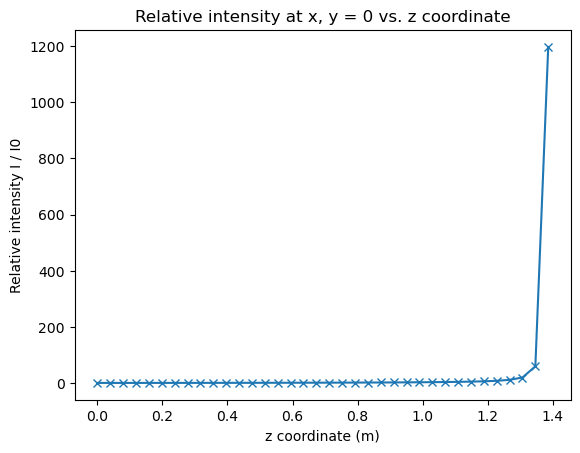

In [28]:
# Plot the diagnostics

plt.plot(z_diag[z_diag < 1.4], intensity_diag[z_diag < 1.4] / intensity_diag[0], linestyle=None, marker='x')
plt.xlabel('z coordinate (m)'); plt.ylabel('Relative intensity I / I0')
plt.title('Relative intensity at x, y = 0 vs. z coordinate')

In [29]:
threshold = (2 * wavenumber * n2 / beta_k)**(1 / (2*K-4))
print(threshold)
print(threshold**2/intensity_diag[0])

652056156.9098524
123.75575230989097


In [ ]:
print(intensity_diag)

[2.45245884e+15 2.46151739e+15 2.47471178e+15 2.49461710e+15
 2.52129690e+15 2.55475569e+15 2.59494612e+15 2.64175198e+15
 2.69498249e+15 2.75437612e+15 2.81961239e+15 2.89032884e+15
 2.96613964e+15 3.04665325e+15 3.13148748e+15 3.22028126e+15
 3.31270308e+15 3.40845662e+15 3.50728395e+15 3.60896703e+15
 3.71332798e+15 3.82022846e+15 3.92956865e+15 4.04128600e+15
 4.15535394e+15 4.27178067e+15 4.39060823e+15 4.51191177e+15
 4.63579916e+15 4.76241098e+15 4.89192090e+15 5.02453647e+15
 5.16050046e+15 5.30009262e+15 5.44363212e+15 5.59148065e+15
 5.74404620e+15 5.90178782e+15 6.06522139e+15 6.23492659e+15
 6.41155537e+15 6.59584219e+15 6.78861648e+15 6.99081769e+15
 7.20351375e+15 7.42792368e+15 7.66544547e+15 7.91769072e+15
 8.18652800e+15 8.47413763e+15 8.78308136e+15 9.11639225e+15
 9.47769166e+15 9.87134356e+15 1.03026612e+16 1.07781876e+16
 1.13060840e+16 1.18966776e+16 1.25632511e+16 1.33232102e+16
 1.41998611e+16 1.52252052e+16 1.64445097e+16 1.79241308e+16
 1.97656569e+16 2.213324

In [ ]:
# Plot the diagnostics

fig, ax = plt.subplots()

# extent maps pixel indices → physical coordinates
extent = [
    x_vector[0], x_vector[-1],     # x-axis (x)
    y_vector[0], y_vector[-1]  # y-axis (y)
]

vmin = intensity.min(); vmax = intensity.max()

im = ax.imshow(
    intensity[0],
    extent=extent,
    origin='lower',
    aspect='auto',
)

ax.set_xlabel('x coordinate (m)')
ax.set_ylabel('y coordinate (m)')
ax.set_title('Intensity at z = 0')

cbar = plt.colorbar(im, ax=ax)
cbar.set_label('Intensity (W / m^2)')

def animate(z):
    im.set_data(intensity[z])
    position = zmin + DeltaZ * number_diagnostic * z; position = round(position, 2)
    ax.set_title(f'Intensity at z = {position} m')
    return [im]

ani = FuncAnimation(
    fig,
    animate,
    frames=intensity.shape[0],
    interval=100,
    blit=True
)

plt.close(fig)
ani

In [ ]:
a = (2 * wavenumber * n2 / beta_k)**(1 / (2 * K - 4))
print(a)
print(a**2)

652056156.9098524
4.25177231764046e+17
